# Sesión 1 – Algoritmos Genéticos (Introducción)

Ciclo de Especialización en Inteligencia Artificial y Big Data

## Objetivos de la sesión
- Comprender qué es un algoritmo genético y su inspiración biológica.
- Identificar los componentes fundamentales de un GA.
- Implementar un primer ejemplo sencillo de optimización.


## 1. ¿Qué es un algoritmo genético?

Un algoritmo genético (GA) es un algoritmo de búsqueda y optimización inspirado en el proceso de selección natural. Mantiene una **población** de soluciones candidatas que evolucionan mediante **selección**, **cruce** y **mutación**.

Se utiliza cuando:
- El espacio de búsqueda es grande o no continuo
- No existe derivada o es costosa de calcular
- Hay múltiples óptimos locales


## 2. Componentes básicos de un GA

- **Individuo**: una solución candidata
- **Cromosoma**: representación del individuo
- **Población**: conjunto de individuos
- **Función de fitness**: mide la calidad de cada solución
- **Operadores genéticos**: selección, cruce y mutación
- **Generación**: una iteración del algoritmo


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 3. Problema de ejemplo

Vamos a **maximizar** la función:

$$f(x) = -(x - 3)^2 + 10$$


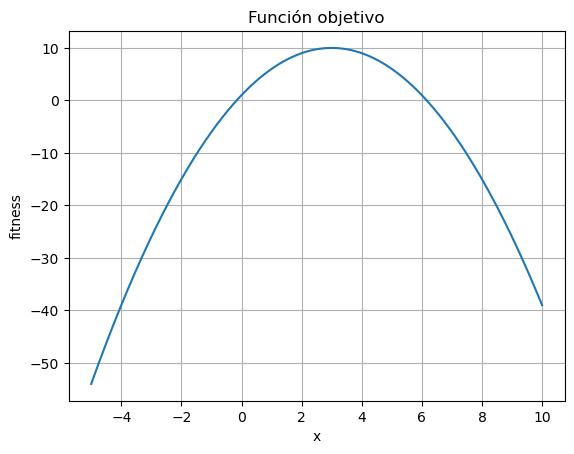

In [2]:
def fitness(x):
    return -(x - 3)**2 + 10

x = np.linspace(-5, 10, 400)
y = fitness(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('fitness')
plt.title('Función objetivo')
plt.grid(True)
plt.show()


## 4. Inicialización de la población


In [3]:
np.random.seed(158)
N = 20
poblacion = np.random.uniform(-5, 10, size=N)
poblacion


array([-3.55595989, -2.67489898,  3.69505522,  3.268251  ,  6.16295723,
        7.31570768,  4.99513336,  5.74033177, -4.68326525,  0.34307082,
       -2.86522414,  9.31670269,  7.38466822, -1.46819841, -0.95391669,
        8.80813685, -0.61459019,  7.30144146,  7.95680404, -1.41858799])

## 5. Evaluación de la población


In [4]:
fitness_vals = fitness(poblacion)
for i, f in enumerate(fitness_vals):
    print(f'Individuo {i}: x = {poblacion[i]:.3f}, fitness = {f:.3f}')


Individuo 0: x = -3.556, fitness = -32.981
Individuo 1: x = -2.675, fitness = -22.204
Individuo 2: x = 3.695, fitness = 9.517
Individuo 3: x = 3.268, fitness = 9.928
Individuo 4: x = 6.163, fitness = -0.004
Individuo 5: x = 7.316, fitness = -8.625
Individuo 6: x = 4.995, fitness = 6.019
Individuo 7: x = 5.740, fitness = 2.491
Individuo 8: x = -4.683, fitness = -49.033
Individuo 9: x = 0.343, fitness = 2.941
Individuo 10: x = -2.865, fitness = -24.401
Individuo 11: x = 9.317, fitness = -29.901
Individuo 12: x = 7.385, fitness = -9.225
Individuo 13: x = -1.468, fitness = -9.965
Individuo 14: x = -0.954, fitness = -5.633
Individuo 15: x = 8.808, fitness = -23.734
Individuo 16: x = -0.615, fitness = -3.065
Individuo 17: x = 7.301, fitness = -8.502
Individuo 18: x = 7.957, fitness = -14.570
Individuo 19: x = -1.419, fitness = -9.524


## 6. Selección por ruleta


In [5]:
fitness_shifted = fitness_vals - fitness_vals.min() + 1e-6
probabilidades = fitness_shifted / fitness_shifted.sum()
padres = np.random.choice(poblacion, size=N, p=probabilidades)
padres

array([ 7.31570768, -1.41858799, -1.41858799, -0.95391669,  3.69505522,
        7.31570768, -1.41858799,  7.30144146,  7.95680404,  7.38466822,
        9.31670269, -0.61459019,  7.38466822,  7.30144146,  3.69505522,
        7.30144146,  6.16295723,  5.74033177,  7.38466822,  6.16295723])

## 7. Mutación


In [6]:
tasa_mutacion = 0.1
mutaciones = np.random.normal(0, tasa_mutacion, size=N)
mutaciones


array([-0.07727202,  0.13882608,  0.02881855,  0.17276124,  0.12799556,
       -0.05493221, -0.05887852, -0.09376255, -0.13092847,  0.04243426,
       -0.12831736,  0.13913836, -0.07424068,  0.0936334 , -0.11084569,
       -0.0292885 , -0.16214136, -0.01737666,  0.04634738, -0.13198976])

In [7]:
nueva_poblacion = padres + mutaciones
nueva_poblacion


array([ 7.23843566, -1.27976191, -1.38976944, -0.78115545,  3.82305078,
        7.26077547, -1.47746651,  7.20767891,  7.82587557,  7.42710248,
        9.18838533, -0.47545183,  7.31042754,  7.39507486,  3.58420953,
        7.27215296,  6.00081587,  5.72295511,  7.43101559,  6.03096747])

## 8. Mejor individuo encontrado


In [8]:
mejor_idx = np.argmax(fitness(nueva_poblacion))
mejor_x = nueva_poblacion[mejor_idx]
mejor_f = fitness(mejor_x)
print(f'Mejor solución encontrada: x = {mejor_x:.4f}, fitness = {mejor_f:.4f}')


Mejor solución encontrada: x = 3.5842, fitness = 9.6587


## 9. Conclusiones

- Implementación básica de un GA
- En próximas sesiones se ampliará a múltiples generaciones y cruce
